In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

#PULIZIA DATASET
df = pd.read_csv("/Users/liadraetta/Desktop/progetti/Projects/tutorial-experiment/directors_full.csv")

variables = ['population', 'gdpNominal']
df[variables] = df[variables].replace(0, np.nan)
df = df.dropna(subset=variables)  # Rimuovi righe con NaN

DISTRIBUTION PER COUNTRY POPULATIONS

In [2]:

bins = [0, 1_000_000, 10_000_000, 100_000_000, 1_000_000_000, np.inf]
labels = ['Microstates','Lower-Middle Population','Upper-Middle Population','Large States','Demographic Giants']

# Applicazione della logica con pd.cut
df['population_bin'] = pd.cut(
    df['population'], 
    bins=bins, 
    labels=labels, 
    right=False #
)

head_tail_counts = df.groupby(['population_bin', 'type'], observed=False).size().unstack(fill_value=0)

print(head_tail_counts)

type                     Head  Long-tail
population_bin                          
Microstates                16         16
Lower-Middle Population  1084        852
Upper-Middle Population  5295       2459
Large States             2463        592
Demographic Giants         87         78


In [3]:
# T-test
for var in ["population"]:
    head_values = df[df['type'] == 'Head'][var].dropna()
    tail_values = df[df['type'] == 'Long-tail'][var].dropna()
    
    t_stat, p_value = ttest_ind(head_values, tail_values)
    print(f"{var}: t={t_stat:.3f}, p={p_value:.3f}")

population: t=10.664, p=0.000


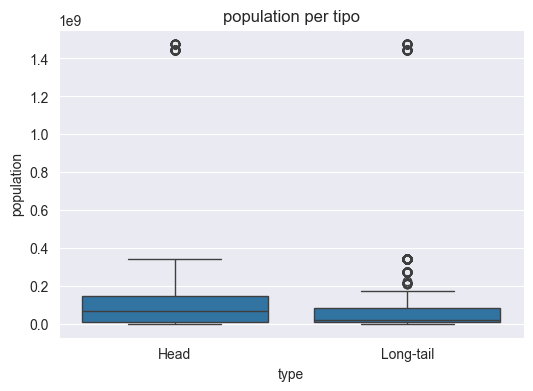

In [4]:
for var in ["population"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='type', y=var, data=df)
    plt.title(f'{var} per tipo')
    plt.show()

DISTRIBUTION PER GDP

In [5]:
# T-test
for var in ["gdpNominal"]:
    head_values = df[df['type'] == 'Head'][var].dropna()
    tail_values = df[df['type'] == 'Long-tail'][var].dropna()
    
    t_stat, p_value = ttest_ind(head_values, tail_values)
    print(f"{var}: t={t_stat:.3f}, p={p_value:.3f}")

gdpNominal: t=26.259, p=0.000


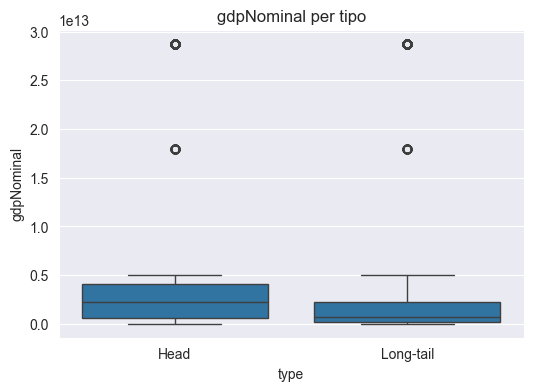

In [6]:
for var in ["gdpNominal"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='type', y=var, data=df)
    plt.title(f'{var} per tipo')
    plt.show()

DISTRIBUTION PER GENDER

In [7]:
gender_counts = df.groupby(['norm_gender', 'type']).size().unstack(fill_value=0)
print(gender_counts)

type         Head  Long-tail
norm_gender                 
Female       1362        963
GenderQueer     7          3
Male         7575       3016


In [8]:
# Test chi-quadro per gender
for cat_var in ['norm_gender']:
    contingency_table = pd.crosstab(df[cat_var], df['type'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"{cat_var}: chi2={chi2:.3f}, p={p:.3f}")

norm_gender: chi2=149.817, p=0.000


type         Head  Long-tail
norm_gender                 
Female       1362        963
GenderQueer     7          3
Male         7575       3016


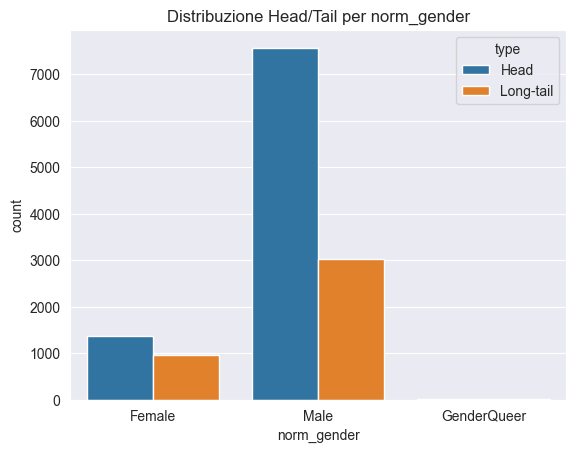

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tabella contingenza
contingency = pd.crosstab(df['norm_gender'], df['type'])
print(contingency)

# Grafico
sns.countplot(x='norm_gender', hue='type', data=df)
plt.title('Distribuzione Head/Tail per norm_gender')
plt.show()

DISTRIBUZION PER unm49

In [10]:
gender_counts = df.groupby(['unm49', 'type']).size().unstack(fill_value=0)
print(gender_counts)

type                       Head  Long-tail
unm49                                     
Australia and New Zealand   228         58
Caribbean                     3          2
Central America              25         11
Central Asia                  8         19
Eastern Africa                4          5
Eastern Asia                197        119
Eastern Europe             1445        646
Middle Africa                 2          2
Northern Africa              43         40
Northern America           2211        260
Northern Europe            1416        765
South America                86         41
South-eastern Asia           27         99
Southern Africa              14          4
Southern Asia                32         40
Southern Europe             634        632
Western Africa               12          5
Western Asia                195        326
Western Europe             2153        800


In [11]:
for cat_var in ['unm49']:
    contingency_table = pd.crosstab(df[cat_var], df['type'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"{cat_var}: chi2={chi2:.3f}, p={p:.3f}")

unm49: chi2=1193.325, p=0.000


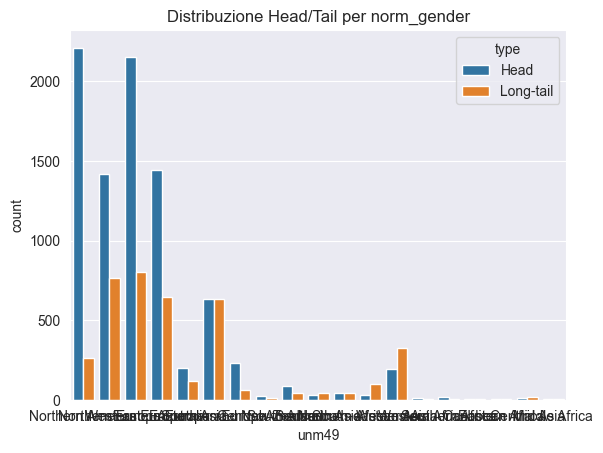

In [12]:
sns.countplot(x='unm49', hue='type', data=df)
plt.title('Distribuzione Head/Tail per norm_gender')
plt.show()

In [53]:
import plotly.express as px

df['gdpNominal'] = pd.to_numeric(df['gdpNominal'], errors='coerce')
fig = px.scatter(
    df, 
    x="claims", 
    y="gdpNominal",
    color="type",       # Colors the dots by gender
    hover_name="label_en",     # Shows the name when you hover
    hover_data=["citizenship"],# Adds extra info to the hover box
    trendline="ols",           # Adds the trendline similar to your image
    title="Relationship between Number of Claims and Nominal GDP",
    labels={
        "claims": "Number of Claims",
        "gdpNominal": "GDP Nominal (USD)"
    }
)

# 4. Improve the layout
fig.update_layout(
    template="plotly_white",
    xaxis_title="Number of Claims",
    yaxis_title="Nominal GDP"
)

# 5. Show the plot
fig.show()